# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cuml.manifold import UMAP
import seaborn as sns
import lightgbm as lgb
import shap
import yaml



from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys
import importlib


# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent.parent


# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria
from funciones.graficos_clusters_pdf  import generar_pdf_clusters
from funciones.distribucion_clusters_pdf  import generar_pdf_distribuciones_clusters

# URLs y Constantes

In [3]:
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')
DATA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lf_k6_perdida4.csv')
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_DICT_URL= os.path.join(DATA_FOLDER, 'data_dict.csv')

CODE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

EXP_URL = os.path.join(CODE_URL, 'DATA', 'EXP')

SEED = 230047

In [4]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_ternaria_lags.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# UTILS

In [33]:
def van_dongen_normalized(contingency):
    n = contingency.values.sum()
    sum_max_rows = contingency.max(axis=1).sum()  # para cada label, max sobre clusters
    sum_max_cols = contingency.max(axis=0).sum()  # para cada cluster, max sobre labels
    max_row_total = contingency.sum(axis=1).max()
    max_col_total = contingency.sum(axis=0).max()
    
    vdn = (2*n - sum_max_rows - sum_max_cols) / (2*n - max_row_total - max_col_total)
    return vdn

# LEEMOS DATOS

In [5]:
df = pd.read_csv(
    DATA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

/tmp/ipykernel_314062/2006570273.py:1: DtypeWarning: Columns (0: ternaria) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [6]:
df.columns

Index(['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip',
       'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad',
       'mrentabilidad_annual', 'mcomisiones',
       ...
       'Visa_madelantodolares_delta_lag_pond',
       'Visa_fultimo_cierre_delta_lag_pond', 'Visa_mpagado_delta_lag_pond',
       'Visa_mpagospesos_delta_lag_pond', 'Visa_mpagosdolares_delta_lag_pond',
       'Visa_fechaalta_delta_lag_pond', 'Visa_mconsumototal_delta_lag_pond',
       'Visa_cconsumos_delta_lag_pond',
       'Visa_cadelantosefectivo_delta_lag_pond',
       'Visa_mpagominimo_delta_lag_pond'],
      dtype='str', length=459)

## Ternaria

In [10]:
# df=ternaria(df)

/home/marco/code/DMEyF/dmeyf2026/funciones/ternaria.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['mes_idx'] = year * 12 + month


In [7]:
df.columns

Index(['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip',
       'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad',
       'mrentabilidad_annual', 'mcomisiones',
       ...
       'Visa_madelantodolares_delta_lag_pond',
       'Visa_fultimo_cierre_delta_lag_pond', 'Visa_mpagado_delta_lag_pond',
       'Visa_mpagospesos_delta_lag_pond', 'Visa_mpagosdolares_delta_lag_pond',
       'Visa_fechaalta_delta_lag_pond', 'Visa_mconsumototal_delta_lag_pond',
       'Visa_cconsumos_delta_lag_pond',
       'Visa_cadelantosefectivo_delta_lag_pond',
       'Visa_mpagominimo_delta_lag_pond'],
      dtype='str', length=459)

# SHAP VALUES

In [8]:
EXPERIMENTO = "HT4942"  #parametros tomados de un experimento sin los lags -> TODO reveer
EXPERIMENT_URL = os.path.join(EXP_URL, EXPERIMENTO)
with open(
    os.path.join(EXPERIMENT_URL, "PARAM.yml"),
    "r",
    encoding="utf-8",
) as archivo:
    PARAM_ORIGEN = yaml.safe_load(archivo)


In [9]:
PARAM_ORIGEN

{'experimento': 4942.0,
 'semilla_primigenia': 230047.0,
 'out': {'lgbm': {'mejores_hiperparametros': {'num_iterations': 2505,
    'learning_rate': 0.0020182,
    'feature_fraction': 0.5707911,
    'num_leaves': 61,
    'min_data_in_leaf': 184,
    'min_sum_hessian_in_leaf': 0.0067274},
   'y': 0.9271928}},
 'train': 202104.0,
 'train_final': 202104.0,
 'future': 202106.0,
 'semilla_kaggle': 314159.0,
 'cortes': [4000.0,
  4500.0,
  5000.0,
  5500.0,
  6000.0,
  6500.0,
  7000.0,
  7500.0,
  8000.0,
  8500.0,
  9000.0,
  9500.0,
  10000.0,
  10500.0,
  11000.0,
  11500.0,
  12000.0,
  12500.0,
  13000.0,
  13500.0,
  14000.0,
  14500.0,
  15000.0,
  15500.0,
  16000.0,
  16500.0,
  17000.0,
  17500.0,
  18000.0,
  18500.0,
  19000.0],
 'hyperparametertuning': {'xval_folds': 5.0},
 'lgbm': {'param_fijos': {'boosting': 'gbdt',
   'objective': 'binary',
   'metric': 'auc',
   'first_metric_only': False,
   'boost_from_average': True,
   'feature_pre_filter': False,
   'force_row_wise': Tr

In [10]:
# Une parámetros fijos con los mejores encontrados por la BO
params_lgb = {
    **PARAM_ORIGEN["lgbm"]["param_fijos"],
    **PARAM_ORIGEN["out"]["lgbm"]["mejores_hiperparametros"],
}

In [11]:
# Ajuste por pasar del undersampling al dataset completo
params_lgb["min_data_in_leaf"] = round(
    params_lgb["min_data_in_leaf"]
    / 0.1
)


In [12]:
parametros_enteros = {
    "verbosity",
    "seed",
    "max_depth",
    "max_bin",
    "max_drop",
    "num_iterations",
    "num_leaves",
    "min_data_in_leaf",
}

for parametro in parametros_enteros:
    if parametro in params_lgb:
        params_lgb[parametro] = int(params_lgb[parametro])

num_boost_round = params_lgb.pop("num_iterations")


In [13]:
params_lgb

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'auc',
 'first_metric_only': False,
 'boost_from_average': True,
 'feature_pre_filter': False,
 'force_row_wise': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'min_sum_hessian_in_leaf': 0.0067274,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'learning_rate': 0.0020182,
 'feature_fraction': 0.5707911,
 'num_leaves': 61,
 'min_data_in_leaf': 1840}

In [14]:
meses_train_final = (
    np.atleast_1d(PARAM_ORIGEN["train_final"])
    .astype(int)
    .tolist()
)

dataset_final = (
    df
    .loc[df["foto_mes"].isin(meses_train_final)]
    .reset_index(drop=True)
)

dataset_final["clase01"] = (
    dataset_final["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

/tmp/ipykernel_314062/739468864.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset_final["clase01"] = (


In [21]:
pd.Series(dataset_final.columns)[pd.Series(dataset_final.columns).str.contains('azar')]

Series([], dtype: str)

In [22]:
columnas_excluidas = {
    "ternaria",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "cprestamos_personales_lag_pond",
    "cprestamos_personales_delta_lag_pond",
    "mprestamos_personales",
    "mprestamos_personales_lag_pond",
    "mprestamos_personales_delta_lag_pond"
}

campos_buenos = [
    columna
    for columna in dataset_final.columns
    if columna not in columnas_excluidas
]


In [23]:
len(campos_buenos)

452

In [24]:
dtrain = lgb.Dataset(
    data=dataset_final[campos_buenos],
    label=dataset_final["clase01"],
    feature_name=campos_buenos,
)

modelo = lgb.train(
    params=params_lgb,
    train_set=dtrain
)

# modelo = lgb.LGBMClassifier()
# modelo.fit(dataset_final[campos_buenos], dataset_final["clase01"])

In [25]:
dfuture_cpu = (
    df
    .loc[df["foto_mes"].isin([202106])]
    .reset_index(drop=True)
)

prediccion = modelo.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion


tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.010938
1,12159858,202106,continua,0.011542
2,12160484,202106,continua,0.012945
3,12160591,202106,continua,0.010767
4,12160747,202106,continua,0.012588


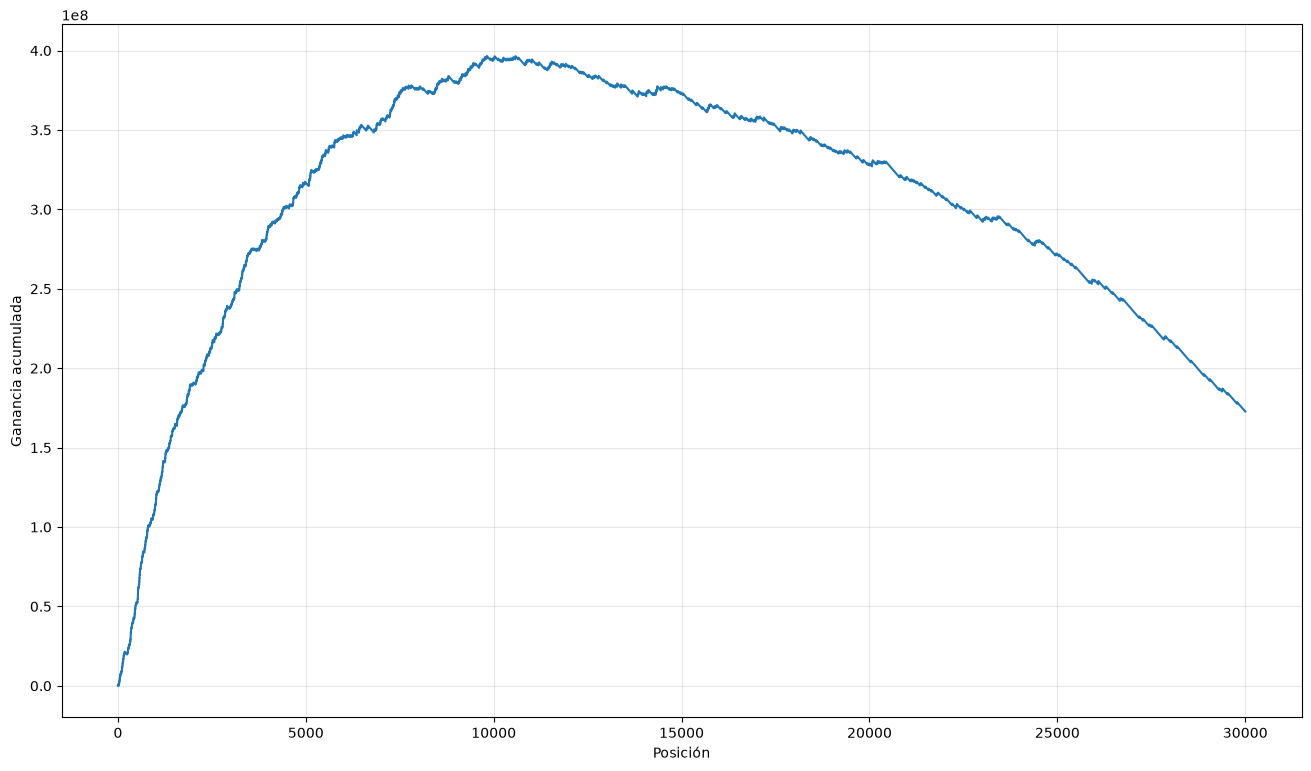

In [26]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# compute SHAP values
explainer = shap.TreeExplainer(modelo)
shap_values = explainer(df[campos_buenos])

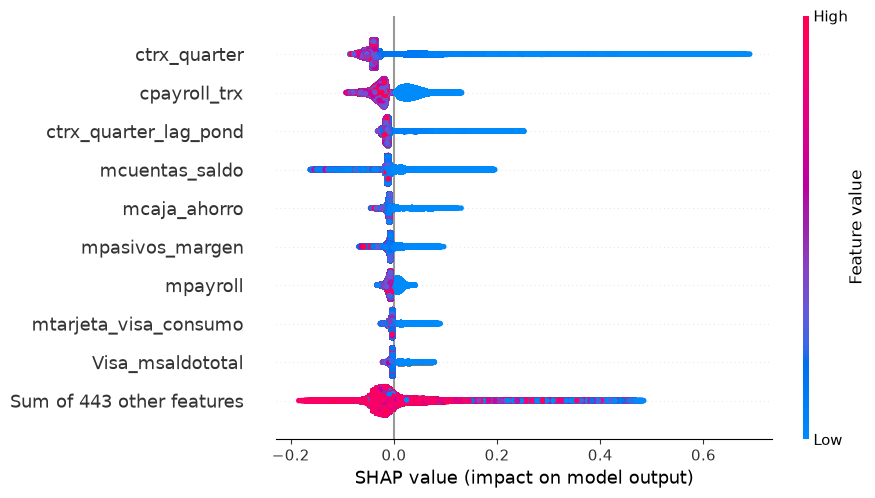

In [28]:
shap.plots.beeswarm(shap_values)

# UMAP to SHAP

In [35]:
# subsampleamos para dejar los baja + subset de continúa.


In [29]:
ternaria = df["ternaria"].str.upper()

mask_baja = ternaria.isin(["BAJA+1", "BAJA+2"])
mask_continua = ternaria.eq("CONTINUA")

df_bajas = df.loc[mask_baja]

df_continua = (
    df.loc[mask_continua]
    .sample(
        n=len(df_bajas) // 5,
        random_state=SEED,
    )
)

df_cluster = (
    pd.concat([df_bajas, df_continua])
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer(df_cluster[campos_buenos])

X_shap = shap_values.values.astype(np.float32, copy=False)

In [30]:
shap_values.shape

(11004, 452)

In [31]:
shap_values[0][0]

.values =
np.float64(9.8398291326573e-06)

.base_values =
np.float64(-4.387391077379289)

.data =
np.float64(49606769.0)

In [34]:
import itertools

N_COMPONENTS = [2, 5, 10]
N_NEIGHBORS = [10, 20, 30, 40]
MIN_DIST = [0.001, 0.1, 0.5]
METRICS = ["euclidean", "cosine"]
N_CLUSTERS = [3, 4, 5, 6]

N_SEEDS = 3
# N_CLUSTERS = 5
SAMPLE_FRAC = 0.5

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(
    len(X_shap),
    size=int(len(X_shap) * SAMPLE_FRAC),
    replace=False,
)

X_sample = X_shap[sample_idx].astype(np.float32, copy=False)

resultados_umap = []

for (
    n_components,
    n_neighbors,
    min_dist,
    metric,
    n_clusters,
) in itertools.product(
    N_COMPONENTS,
    N_NEIGHBORS,
    MIN_DIST,
    METRICS,
    N_CLUSTERS,
):
    metricas = {
        "sil": [],
        "db": [],
        "ch": [],
    }

    clusters_semillas = []

    for seed in range(SEED, SEED + N_SEEDS):
        print('**step**')
        reducer = UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            build_algo="nn_descent",
            output_type="numpy",
            random_state=seed,
        );

        embedding = reducer.fit_transform(X_sample)

        labels_cluster = KMeans(
            n_clusters=n_clusters,
            random_state=seed,
        ).fit_predict(embedding)

        clusters_semillas.append(labels_cluster)

        metricas["sil"].append(
            silhouette_score(
                embedding,
                labels_cluster,
                sample_size=20_000,
                random_state=seed,
            )
        )
        metricas["db"].append(
            davies_bouldin_score(embedding, labels_cluster)
        )
        metricas["ch"].append(
            calinski_harabasz_score(embedding, labels_cluster)
        )

    ari, nmi, vdn = [], [], []

    for labels_a, labels_b in itertools.combinations(clusters_semillas, 2):
        ari.append(adjusted_rand_score(labels_a, labels_b))
        nmi.append(normalized_mutual_info_score(labels_a, labels_b))

        contingency = pd.crosstab(
            pd.Series(labels_a, name="cluster_a"),
            pd.Series(labels_b, name="cluster_b"),
        )
        vdn.append(van_dongen_normalized(contingency))

    resultados_umap.append({
        "n_clusters": n_clusters,
        "n_components": n_components,
        "n_neighbors": n_neighbors,
        "min_dist": min_dist,
        "metric": metric,
        "sil": np.mean(metricas["sil"]),
        "db": np.mean(metricas["db"]),
        "ch": np.mean(metricas["ch"]),
        "ari_estabilidad": np.mean(ari),
        "nmi_estabilidad": np.mean(nmi),
        "vdn_estabilidad": np.mean(vdn),
        "s_sil": np.std(metricas["sil"]),
        "s_db": np.std(metricas["db"]),
        "s_ch": np.std(metricas["ch"]),
        "s_ari": np.std(ari),
        "s_nmi": np.std(nmi),
        "s_vdn": np.std(vdn),
    })

resultados_umap = pd.DataFrame(resultados_umap)

**step**


/home/marco/anaconda3/envs/cmeyf-cuda13/lib/python3.11/site-packages/cuml/internals/outputs.py:874: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


**step**


/home/marco/anaconda3/envs/cmeyf-cuda13/lib/python3.11/site-packages/cuml/internals/outputs.py:874: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


**step**


...

/home/marco/anaconda3/envs/cmeyf-cuda13/lib/python3.11/site-packages/cuml/internals/outputs.py:874: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


**step**


/home/marco/anaconda3/envs/cmeyf-cuda13/lib/python3.11/site-packages/cuml/internals/outputs.py:874: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


**step**


/home/marco/anaconda3/envs/cmeyf-cuda13/lib/python3.11/site-packages/cuml/internals/outputs.py:874: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


In [35]:
filename = 'cluster_shap_ouput_frac_lags.csv'
output_file = os.path.join( os.getcwd(),  filename)
resultados_umap.to_csv(filename)

In [37]:
resultados_umap.sort_values(by='sil', ascending=False).head(20)

,n_clusters,n_components,n_neighbors,min_dist,metric,sil,db,ch,ari_estabilidad,nmi_estabilidad,vdn_estabilidad,s_sil,s_db,s_ch,s_ari,s_nmi,s_vdn
171,6,5,40,0.001,euclidean,0.700345,0.556203,7675.687957,0.807890,0.892680,0.128560,0.008993,0.005675,813.614291,0.069474,3.753262e-02,0.048149
179,6,5,40,0.100,euclidean,0.693688,0.550442,7323.294287,1.000000,1.000000,0.000000,0.002889,0.010934,279.664053,0.000000,0.000000e+00,0.000000
155,6,5,30,0.100,euclidean,0.685797,0.544712,7063.178103,0.745413,0.878437,0.169488,0.006629,0.020937,913.140531,0.129636,5.167126e-02,0.088143
147,6,5,30,0.001,euclidean,0.679593,0.630033,6089.339546,0.732342,0.846648,0.203311,0.012694,0.043282,1011.671707,0.053399,1.726344e-02,0.014058
127,6,5,20,0.001,cosine,0.674601,0.484814,7538.277383,0.999625,0.999406,0.000189,0.000985,0.001771,47.479536,0.000265,4.200317e-04,0.000134
183,6,5,40,0.100,cosine,0.673999,0.464009,10681.413347,0.944803,0.964020,0.030783,0.003579,0.010391,106.048347,0.039030,2.544194e-02,0.021767
131,6,5,20,0.100,euclidean,0.663843,0.633819,5996.600699,0.757046,0.877962,0.149683,0.016017,0.028801,565.552954,0.092534,4.535953e-02,0.062626
135,6,5,20,0.100,cosine,0.661495,0.498500,7559.736421,1.000000,1.000000,0.000000,0.002515,0.003162,150.864458,0.000000,1.281975e-16,0.000000
175,6,5,40,0.001,cosine,0.660063,0.495135,9364.721295,0.786508,0.892247,0.121364,0.053223,0.084623,2309.094348,0.150962,7.619271e-02,0.085817
275,6,10,40,0.100,euclidean,0.657534,0.782119,4113.624202,0.887568,0.938568,0.097362,0.010191,0.003405,78.863939,0.079147,4.283586e-02,0.068669


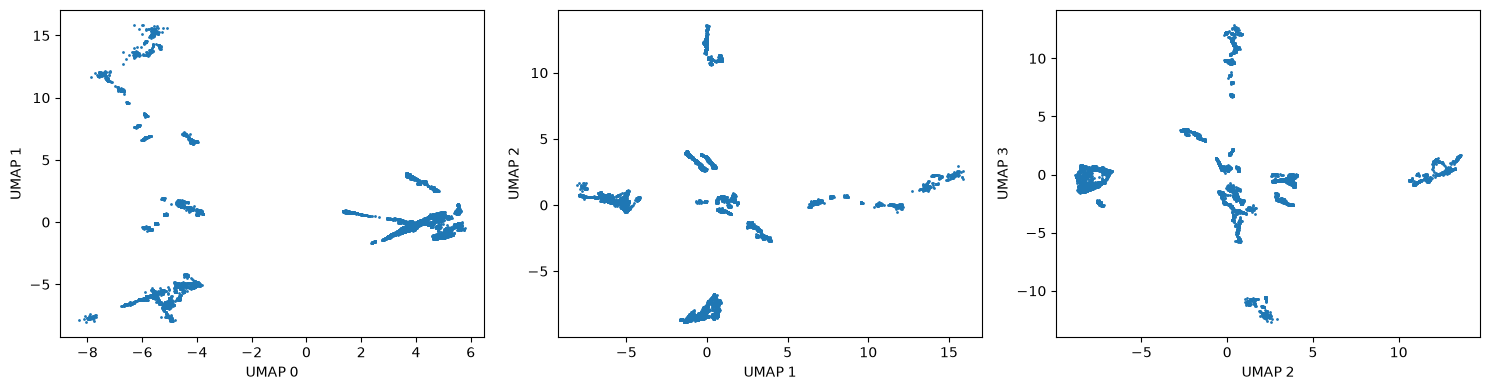

In [38]:
umap_2d = UMAP(
    n_components=5,
    n_neighbors=40,
    min_dist=0.001,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
    ax.scatter(umap_2d[:, x], umap_2d[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

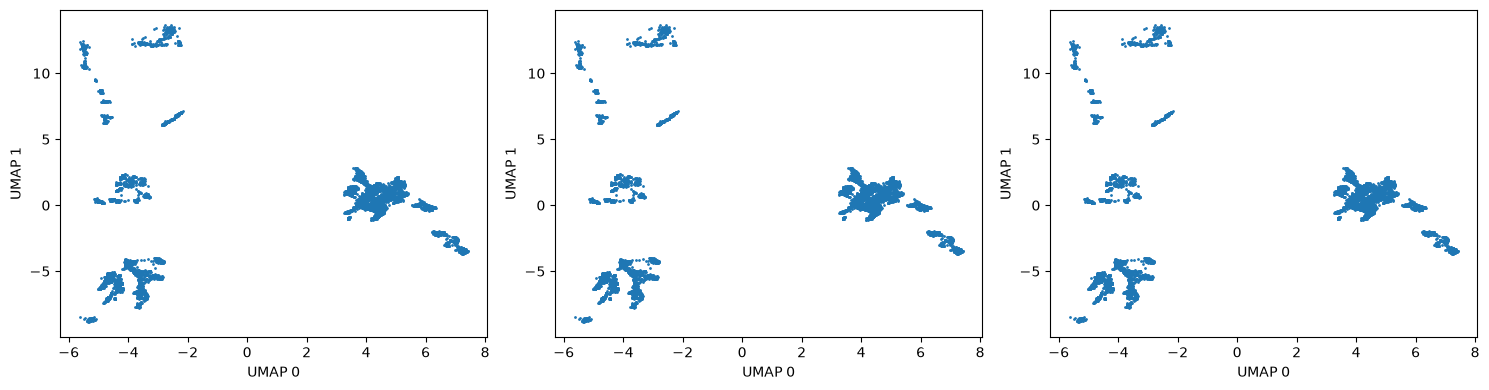

In [39]:
umap_2d = UMAP(
    n_components=5,
    n_neighbors=40,
    min_dist=0.1,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (0, 1), (0, 1)]):
    ax.scatter(umap_2d[:, x], umap_2d[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

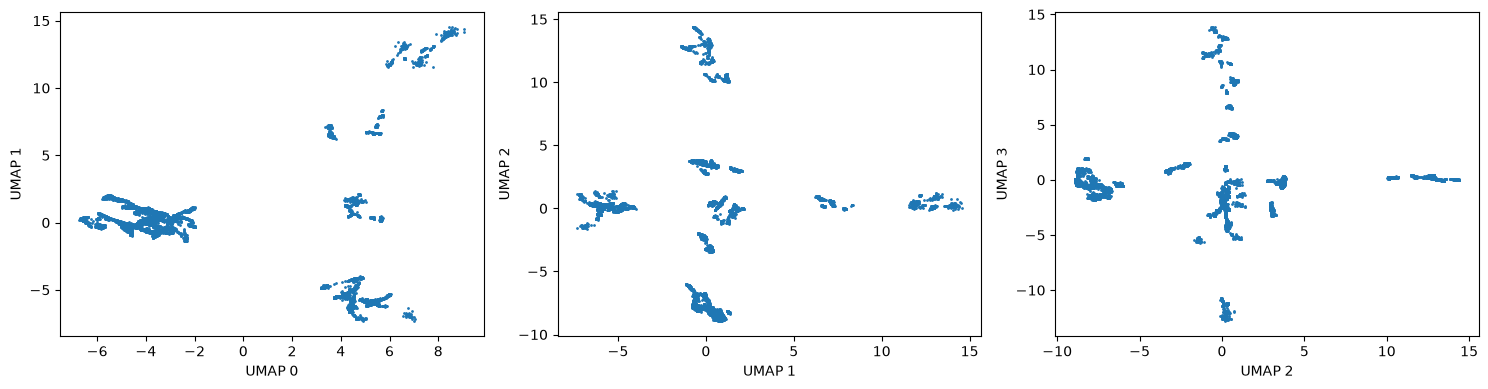

In [40]:
umap_2d = UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.001,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (1, 2), (2, 3)]):
    ax.scatter(umap_2d[:, x], umap_2d[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

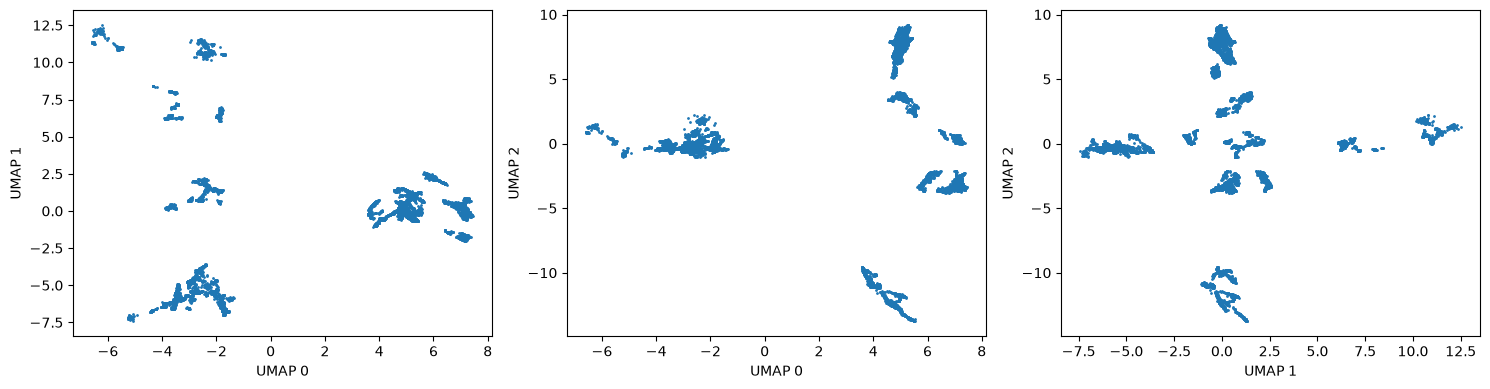

In [41]:
umap_2d = UMAP(
    n_components=5,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    ax.scatter(umap_2d[:, x], umap_2d[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()

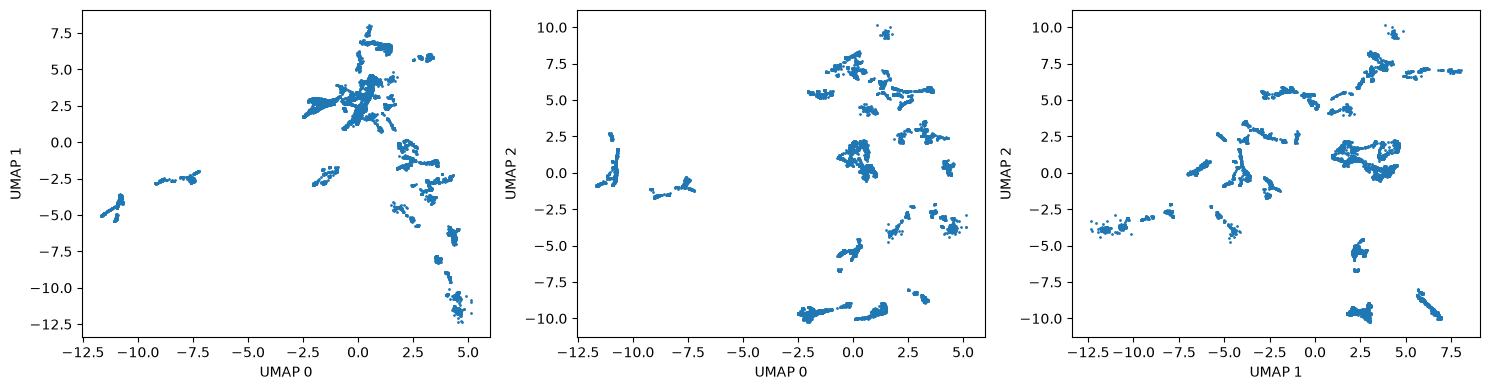

In [42]:
umap_2d = UMAP(
    n_components=5,
    n_neighbors=20,
    min_dist=0.001,
    metric='cosine',
    build_algo="nn_descent",
    output_type="numpy",
).fit_transform(X_shap)
# Ploteams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    ax.scatter(umap_2d[:, x], umap_2d[:, y], s=1)
    ax.set(xlabel=f"UMAP {x}", ylabel=f"UMAP {y}")
plt.tight_layout()
plt.show()